# Exploratory Data Analysis (EDA)

## Business Problem

A telecommunications company wants to predict which customers are likely to leave (churn)

### Goal

- Understand customer behavior.
- Discover factors affecting churn.
- Prepare the dataset for machine learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Pandas is used for data manipulation, NumPy for numerical operations, Matplotlib and Seaborn for visualization.

## Load the Dataset

In [3]:
df =pd.read_csv("../datasets/raw/Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Based on the data what we see it is a supervised classification dataset.

- Dataset contains customer demographic information.
- Service usage.
- Billing information.
- Target variable (Churn).

In [5]:
df.shape

(7043, 21)

Inside this dataset there are 21 columns and 7043 rows.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Most of the columns are categorical or something category and numeric combined.

3 of the columns are numeric.

There are 1 float, 2 int and 18 object type of data present in the dataset.

- Also the TotalCharges is stored as object instead of numeric.
- Churn is our target variable.

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- Mean for SeniorCitizen, tenure and MonthlyCharges are 0.162, 32.37 and 64.76.
- Standard Deviation are 0.36 for SeniorCitizen, 24.55 for tenure, 30.09 for MonthlyCharges
- min values are 0 for SeniorCitizen, 0 for tenure, 18.25 for MonthlyCharges
- max values are 1 for SeniorCitizen, 72 for tenure, 118.75 for MonthlyCharges
- No visible outlier found. Though further analysis needed.

In [8]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


- gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn for all this has 2 uniq value.
- MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract, for all this has 3 uniq value.
- PaymentMethod has 4 uniq value.
- TotalCharges has most uniq value.

- For gender frequently we get Male 3555 count.
- For InternetService frequently we get Fiber optic 3096 count.
- For PaymentMethod frequently we get Electronic check 2365 count.
- For Churn frequently we get No 5174 count.

In [9]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No NaN or Null values found.

In [10]:
(df["TotalCharges"]==" ").sum()

np.int64(11)

Although there are no Null values found in data, But for TotalCharges we get 11 blank strings value.

In [11]:
df.duplicated().sum()

np.int64(0)

No duplicate records found.

In [12]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [13]:
df["TotalCharges"].isna().sum()

np.int64(11)

some of the value in TotalCharges is empty string so when we convert them to numeric it became NaN value.

In [14]:
df["TotalCharges"].fillna(0,inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_15864\2201171674.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(0,inplace=True)


We just fill those NaN value with 0

In [15]:
cat_cols = df.select_dtypes(include="object").columns

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

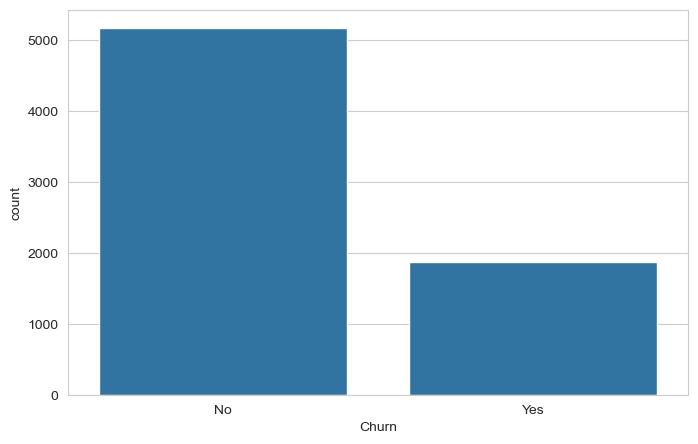

In [16]:
sns.countplot(data=df, x="Churn")
plt.show()

Approximately 73% of customers stay while 27% left. The dataset is moderately imbalanced but still suitable for classification.

- No count is more than 5000
- Yes count is less than 2000

<Axes: xlabel='gender', ylabel='count'>

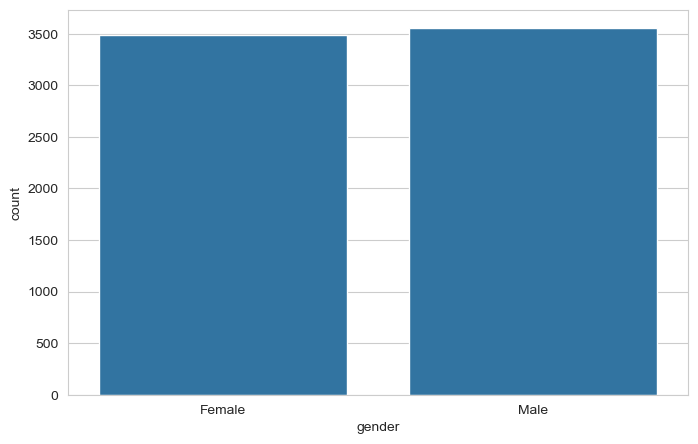

In [17]:
sns.countplot(data=df, x="gender")

Male customer count are more than Female customer.
But the difference is minimal.

<Axes: xlabel='SeniorCitizen', ylabel='count'>

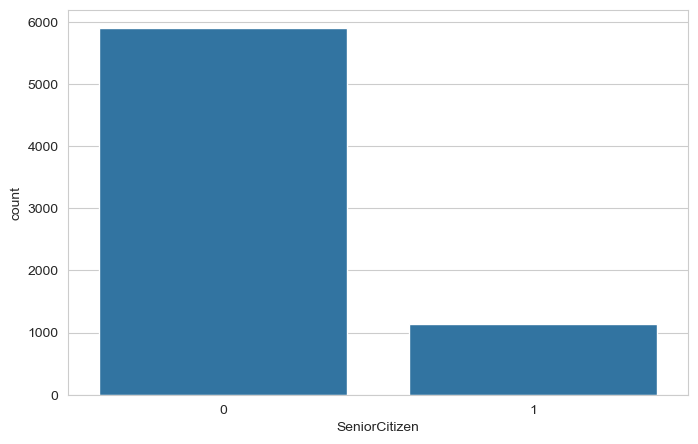

In [18]:
sns.countplot(data=df, x="SeniorCitizen")

Approximately 23% are SeniorCitizen while rest of them are NewCitizen.

<Axes: xlabel='Contract', ylabel='count'>

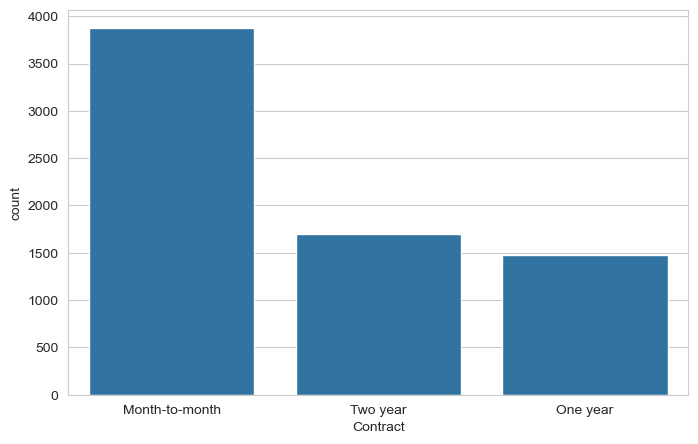

In [19]:
sns.countplot(data=df, x="Contract", order=df["Contract"].value_counts().index)

The analysis indicates that customers demonstrate a clear preference for month-to-month contracts over alternative contract types.

- Month-to-month contract count 3800 or more.
- Two year Contract count 1700 can be more or less.
- One year count 1490 can be less.

<Axes: xlabel='InternetService', ylabel='count'>

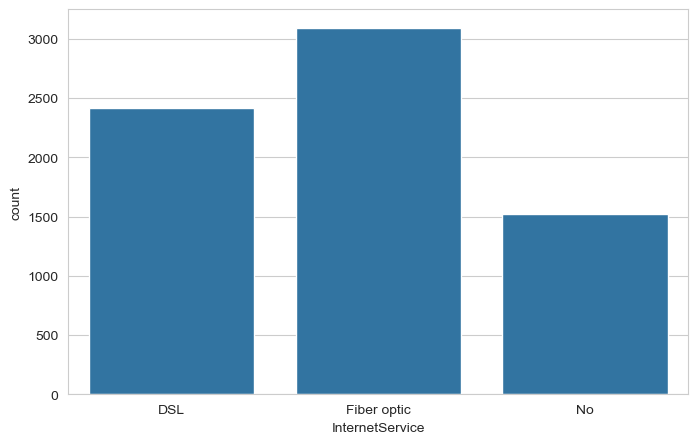

In [20]:
sns.countplot(data=df, x="InternetService")

The Plot indicate customer prefer Fiber optic internetService over other InterService.

- More than 3000 customer prefer Fiber optic InternetService.
- Less than 2500 customer prefer DSL.
- More than 1500 customer did not prefer any of the InternetService.

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

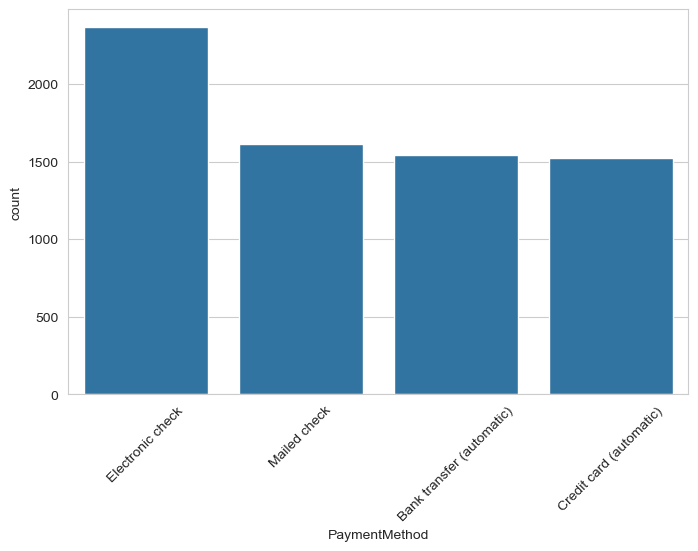

In [21]:
sns.countplot(data=df, x="PaymentMethod")

plt.xticks(rotation=45)

Based on the analysis customer prefer Electronic check then other PaymentMethod.

- Like 2400 customer prefer Electronic check over other PaymentMethod.
- Mailed check, Bank transfer, Credit card are very close in count more than 1500.

<Axes: xlabel='tenure', ylabel='Count'>

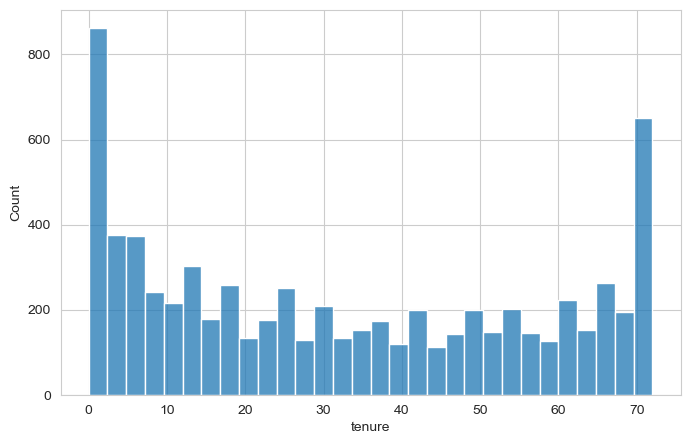

In [22]:
sns.histplot(df["tenure"], bins=30)

- Peaks around 0-1 who are newly joined customer. More than 800 customer are there.
- Second most peak count are around 70-72 who are long term customer. More than 600 customer are there.
- Uniform distribution in the middle 10-65 counts hover mostly between 100-300. The dip in the middle implies that customers who survive past the initial period tend to either churn moderately over time or stick around.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

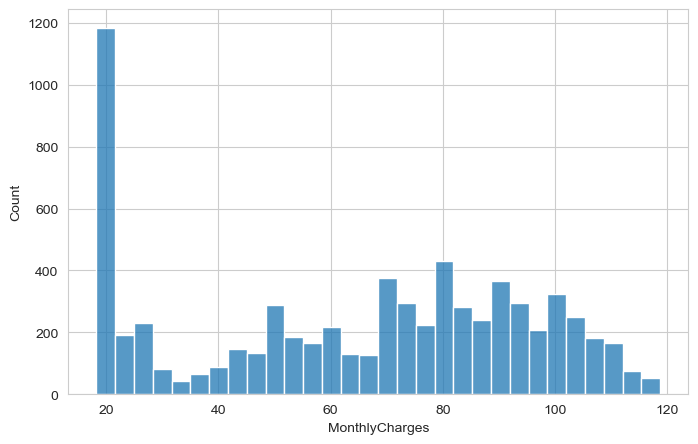

In [23]:
sns.histplot(df["MonthlyCharges"], bins=30)

- Massive spike at $20: Over 1150 customers are grouped right around there. More likely this is by far most common charges, likely corresponding to a basic/entry-level plane.
- Sharpe drop around $20-25.
- Around $45-100: Counts climb back up and fluctuate between 150-430, with a soft peak around $70-90. In here a large number of customers grouped on mid to premium plans.
- From $100-120 counts dropped steadily toward $120, indicating fewer customers on the most expensive plans. Mostly because customer think it is a trap deal.

<Axes: xlabel='TotalCharges', ylabel='Count'>

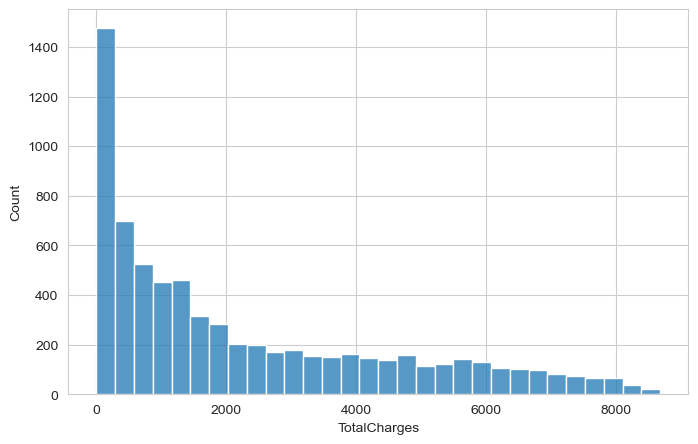

In [24]:
sns.histplot(df["TotalCharges"], bins=30)

- The distribution is heavily concentrated at the low end and tapers off gradually toward higher values.
- Nearly 1500 customer fall in the $0-500 bin.
- Around $500-2000: Counts fall quickly from 700 to 200-300, indicating the pattern of new customers who haven't accumulated much total spend yet.
- Around $2000-8500: Counts stay low and relatively flat. Which represent customers who have around longer and accumulated higher total charges.

In [25]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
)

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


- For Both Female and Male Churn count really close.

<Axes: xlabel='gender', ylabel='count'>

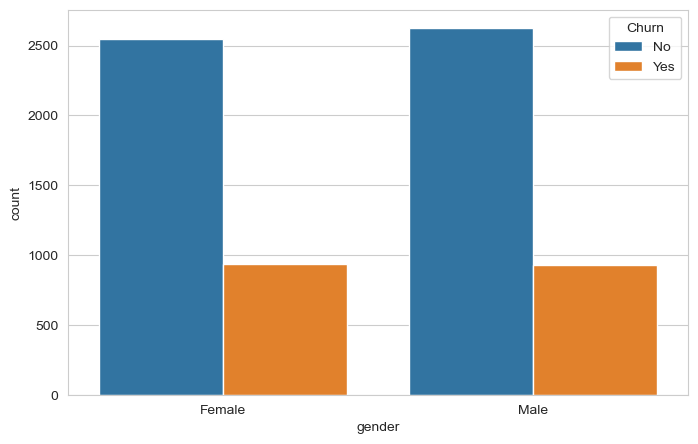

In [26]:
sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

Churn rate appears similar for males nad females, suggesting gender has little influence.

<Axes: xlabel='Contract', ylabel='count'>

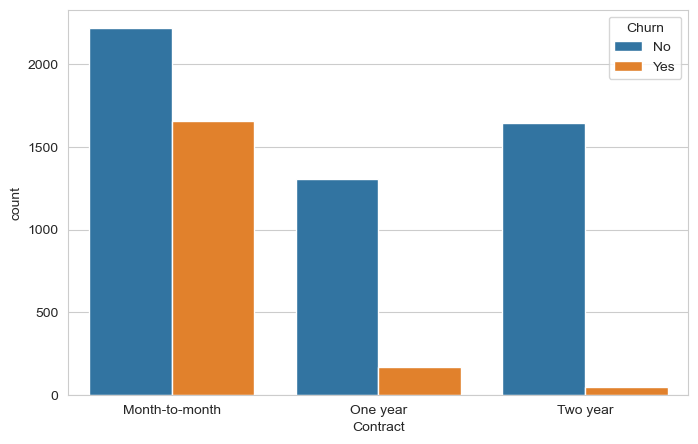

In [27]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

- Month-to-month: 2220 stayed (No), 1655 left (Yes)- a churn rate roughly 43%. This is by far the highest churn rate and the largest customer base.
- One year: 1300 stayed, only 170 left- a churn rate of roughly 11%.
- Two year: 1645 stayed, only 48 left- a churn rate of roughly 3%, the lowest by far.

<Axes: xlabel='InternetService', ylabel='count'>

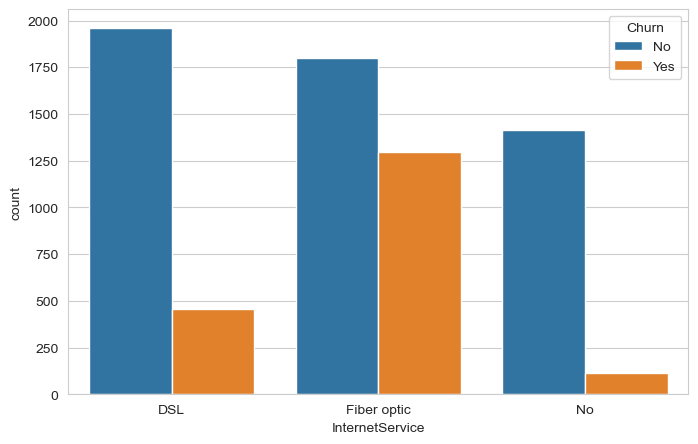

In [28]:
sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

- DSL: 1960 stayed (No), 460 left (Yes)- a churn rate roughly 19%.
- Fiber optic: 1800 stayed, only 1300 left- a churn rate of roughly 42%, the highest of the three groups by far.
- No internet service: 1415 stayed, only 115 left- a churn rate of roughly 7%, the lowest by far.

<Axes: xlabel='PaymentMethod', ylabel='count'>

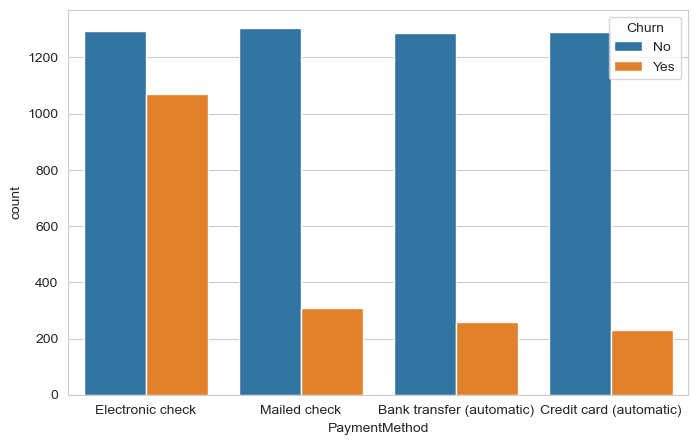

In [29]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

- Electronic check: 1360 stayed (No), 1140 left (Yes)- a churn rate roughly 47%. This is by far the highest churn rate.
- Mailed check: 1365 stayed, only 250 left- a churn rate of roughly 15%.
- Bank transfer: 1355 stayed, only 220 left- a churn rate of roughly 12%.
- Credit card: 1355 stayed, only 210 left- a churn rate of roughly 10%, the lowest by far.

<Axes: xlabel='PaperlessBilling', ylabel='count'>

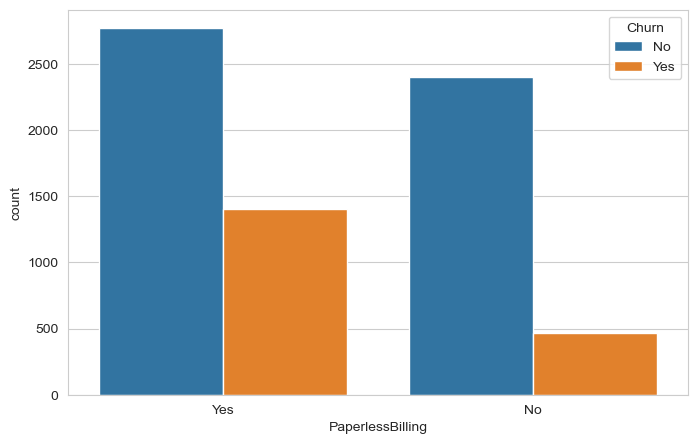

In [30]:
sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

- PaperlessBilling = Yes: ~2,780 stayed, ~1,400 left — churn rate of roughly 33%.
- PaperlessBilling = No: ~2,400 stayed, ~470 left — churn rate of roughly 16%.

<Axes: xlabel='Churn', ylabel='tenure'>

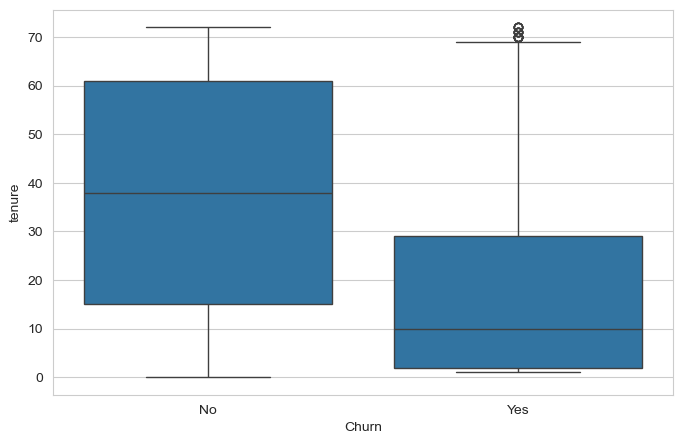

In [31]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

1. Churn = No (retained customers):
 - Median tenure ≈ 38 months
 - IQR (box) spans roughly 15–61 months
 - Whiskers extend from 0 to 72 (full range), no real outliers
2. Churn = Yes (churned customers):
 - Median tenure ≈ 10 months — dramatically lower
 - IQR (box) spans roughly 2–29 months
 - A few outliers (small circles) near 70–72 months — a handful of long-tenured customers who still  churned, despite being atypical

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

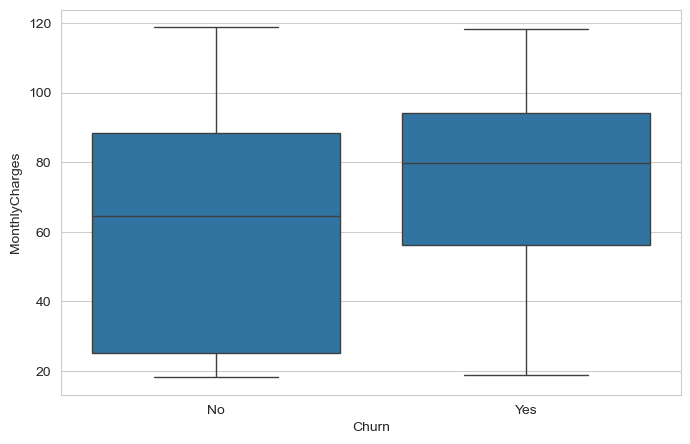

In [32]:
sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

1. Churn = No (retained customers):
 - Median tenure ≈ $64
 - IQR (box) spans roughly $25–85
 - Whiskers extend from 18 to 118 (full range), no real outliers
2. Churn = Yes (churned customers):
 - Median tenure ≈ $79 — dramatically higher
 - IQR (box) spans roughly $58–93, no real outliers

<Axes: xlabel='Churn', ylabel='TotalCharges'>

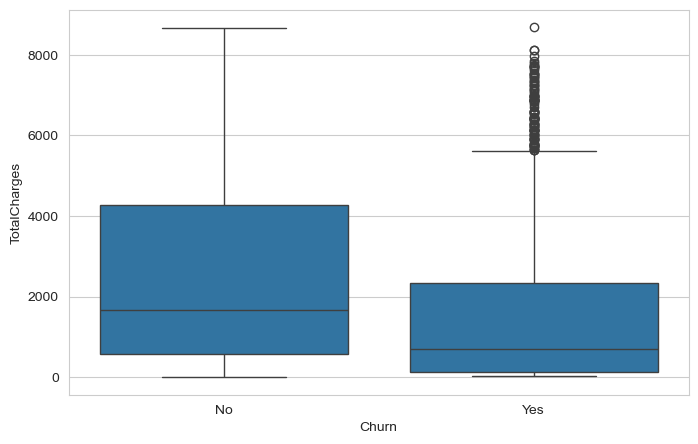

In [33]:
sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

1. Churn = No (retained customers):
 - Median tenure ≈ $1750 - dramatically lower
 - IQR (box) spans roughly $815–4350
 - Whiskers extend from 0 to 9270 (full range), no real outliers
2. Churn = Yes (churned customers):
 - Median tenure ≈ $450 — dramatically lower
 - IQR (box) spans roughly $120–2250
 - A vast amount of outliers (small circles) near $5970–9450 — a handful of long-tenured customers who still  churned, despite being atypical

In [34]:
temp = df.copy()

In [35]:
temp = temp.drop(columns=["customerID"])

In [36]:
temp["Churn"] = temp["Churn"].map({
    "No":0,
    "Yes":1
})

In [37]:
temp = pd.get_dummies(temp, drop_first=True)

In [38]:
corr = temp.corr()

<Axes: >

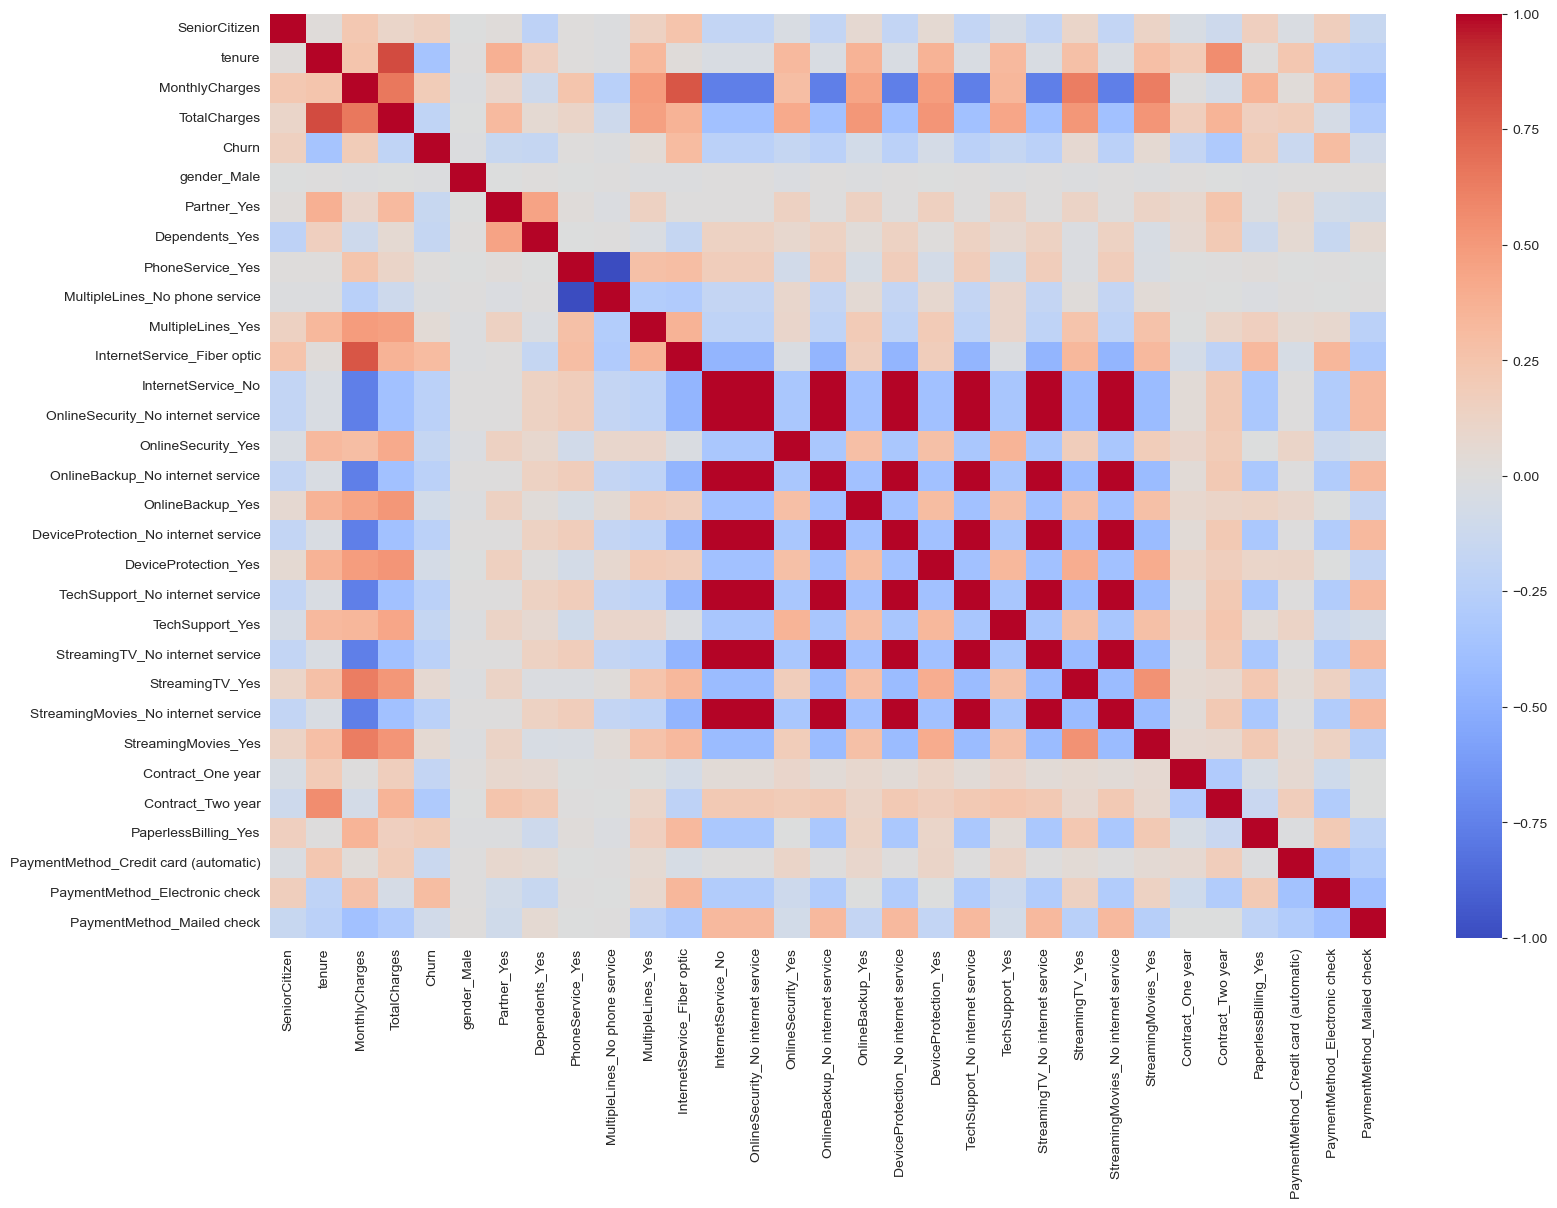

In [39]:
plt.figure(figsize=(18, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

1. Core numeric relationships (top-left block):

- tenure ↔ TotalCharges: Strong positive correlation (deep red, likely ~0.8+) — confirms that Longer-tenured customers have paid more in total, which is mathematically expected.
- MonthlyCharges ↔ TotalCharges: Also strongly positive, though slightly weaker than tenure↔TotalCharges.
- tenure ↔ MonthlyCharges: Weak/near-zero — tenure and monthly price aren't strongly related on their own.

2. Churn correlations (row 5 — the one you care about most):

- Churn ↔ tenure: Clearly negative (light blue) — confirms that shorter tenure → higher churn.
- Churn ↔ MonthlyCharges: Positive (light orange/red) — higher monthly charges → higher churn, consistent with the fiber optic finding.
- Churn ↔ Contract_Two year: Negative — two-year contracts reduce churn, consistent with that contract bar chart.
- Churn ↔ InternetService_Fiber optic: Positive — fiber customers churn more, consistent with that earlier chart.
- Churn ↔ PaperlessBilling_Yes: Slightly positive, consistent with that chart too.
- Churn ↔ OnlineSecurity_Yes / TechSupport_Yes: Usually negative in this dataset — customers without these add-ons tend to churn more (people who invest in support/security services are stickier).

3. The big dark-red block (middle of the heatmap):
This is the most visually striking part — a large cluster of near-perfect correlations (dark red) among:
OnlineSecurity_No internet service, OnlineBackup_No internet service, DeviceProtection_No internet service, TechSupport_No internet service, StreamingTV_No internet service, StreamingMovies_No internet service, and InternetService_No.

- This isn't a real insight — it's a structural artifact of one-hot encoding. If a customer has no internet service, then by definition they also have "No internet service" for OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, and StreamingMovies simultaneously. These columns are perfectly collinear with each other (correlation ≈ 1.0).

4. Other notable near-zero / weak areas:

- gender_Male correlates with almost nothing — gender isn't a meaningful churn driver here.
- PhoneService_Yes ↔ MultipleLines_No phone service: Strong negative (near -1).

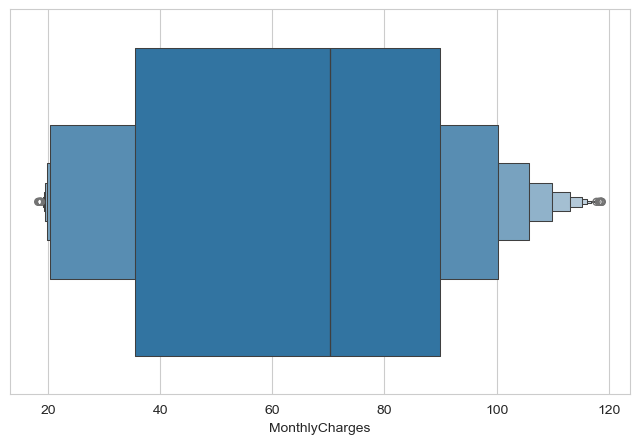

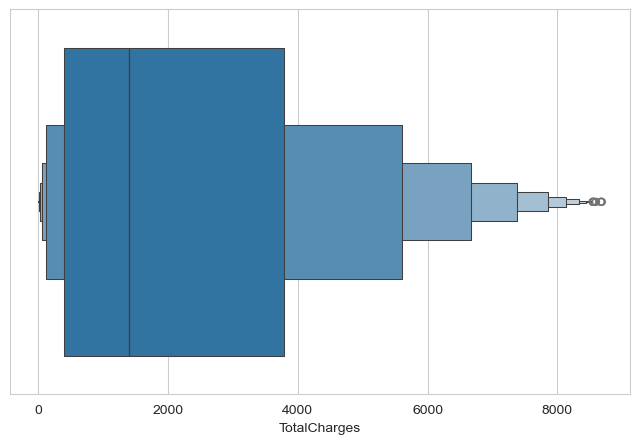

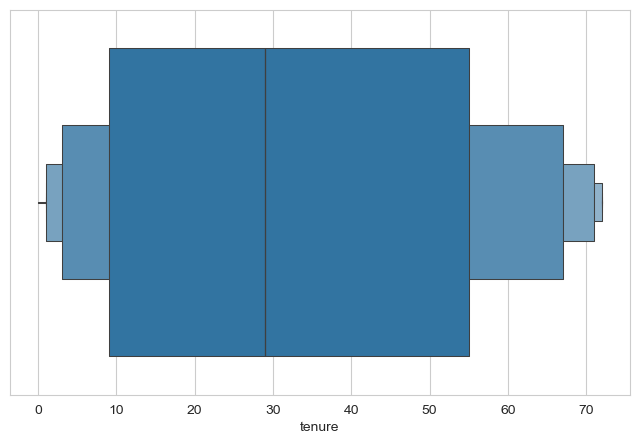

In [40]:
for col in ["MonthlyCharges", "TotalCharges", "tenure"]:
    sns.boxenplot(x=df[col])
    plt.show()

Outliers represent genuine customer behavior rather than data entry errors, so they should generally be retained.

# Key Business Insights: Customer Churn Analysis

1. Contract type is the single strongest churn driver.
Month-to-mont customers churn at ~43%, compare to ~11% for one-year and just ~3% for two-year contracts. Customers value the flexibility of month-to-month plans, but that same flexibility is what makes them easy to leave.

##### Action: Incentivize migration to longer-term contracts through discounts, loyalty pricing or bundled perks for 1-2 year commitments.

2. Churn is concentrated in the first year of the customer lifecycle.
Median tenure for churned customers is ~10 months vs. ~38 months for retained customers. Most attrition happens early — likely tied to onboarding experience, initial pricing shock, or unmet expectations.

##### Action: Build a "first 90 days" retention program — proactive check-ins, onboarding support, or early-tenure discounts to get customers past the highest-risk window.

3. Fiber optic customers churn at more than 2x the rate of DSL customers (~42% vs ~19%).
This is counterintuitive since fiber is the "premium" product, but it correlates strongly with higher MonthlyCharges, suggesting a cost-to-value mismatch or service quality/reliability complaints.

##### Action: Investigate fiber customer satisfaction and support tickets directly — this looks like a price/value or service-quality issue rather than a product-fit issue.

4. Higher MonthlyCharges correlate with higher churn.
The $70–100 pricing tier (largely fiber + add-on bundles) shows the highest concentration of both customers and churn risk.

##### Action: Review pricing tiers in this range — consider tiered loyalty discounts or clearer value communication (e.g., bundling justification) for customers in this bracket.

5. Lack of support/security add-ons is linked to higher churn.
Customers without OnlineSecurity or TechSupport churn more than those with these services — customers who invest in "peace of mind" services tend to be stickier.

##### Action: Promote or bundle OnlineSecurity/TechSupport as retention tools, not just upsells — frame them as churn-reduction levers in customer success conversations.

6. PaperlessBilling customers churn ~2x more than non-paperless customers (~33% vs ~16%).
This is likely a proxy signal (younger/more price-sensitive customers) rather than an independent cause — it overlaps heavily with month-to-month and fiber segments.

##### Action: Treat as a secondary indicator, not a standalone lever — don't design retention offers around billing method alone.

7. Highest-risk customer profile ("perfect storm" segment):
Month-to-month contract + Fiber optic internet + Low tenure (<12 months) + Paperless billing. This combination is very likely your top churn-risk segment and should be the primary target for retention campaigns.

##### Action: Build a targeted retention/win-back campaign specifically for this segment — e.g., early loyalty discount, proactive outreach, or contract-upgrade incentive.

In [42]:
df.to_csv("../datasets/processed/cleaned_telco.csv", index=False)